# NLP Pipeline on IMDB Movie Reviews

This project applies a full NLP pipeline on 2000 IMDB movie reviews. 
The pipeline covers:
- Text Preprocessing (HTML removal, punctuation, stopwords, lemmatization)
- Bigram Analysis (positive vs negative reviews)
- Named Entity Recognition (most mentioned persons)
- Sentiment Classification (Logistic Regression, Naive Bayes, Linear SVM)

**Best Model:** Linear SVM — 83.6% accuracy
**Dataset:** IMDB 50K Movie Reviews (Kaggle)

## Libraries
Importing all necessary libraries for text processing, machine learning, and visualization.

In [1]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re
from nltk.stem import WordNetLemmatizer
import spacy
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB

## Dataset
Loading 2000 reviews from the IMDB 50K Movie Reviews dataset. Each review is labeled as positive or negative.

In [2]:
#importing the IMDB Dataset 
data = pd.read_csv("IMDB Dataset.csv",nrows = 2000)

In [3]:
print(data.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


## Text Preprocessing
Cleaning the raw text by removing HTML tags, punctuation, stopwords, and reducing words to their base form using lemmatization. The word "not" is intentionally kept as it carries important sentiment meaning.

In [4]:
x = data["review"]
y = data["sentiment"]

In [5]:
data["no_punct"] = x.apply(lambda y :  re.sub(r"<.*?>|([^\w\s])",  "", y))

In [6]:
data["no_punct"]

0       One of the other reviewers has mentioned that ...
1       A wonderful little production The filming tech...
2       I thought this was a wonderful way to spend ti...
3       Basically theres a family where a little boy J...
4       Petter Matteis Love in the Time of Money is a ...
                              ...                        
1995    Feeling Minnesota directed by Steven Baigelman...
1996    THE CELL 2000 Rating 810The Cell like Antz mus...
1997    This movie despite its list of B C and D list ...
1998    I loved this movie It was all I could do not t...
1999    This was the worst movie I have ever seen Bill...
Name: no_punct, Length: 2000, dtype: object

In [7]:
data["lower"]= data["no_punct"].str.lower()

In [8]:
data["lower"]

0       one of the other reviewers has mentioned that ...
1       a wonderful little production the filming tech...
2       i thought this was a wonderful way to spend ti...
3       basically theres a family where a little boy j...
4       petter matteis love in the time of money is a ...
                              ...                        
1995    feeling minnesota directed by steven baigelman...
1996    the cell 2000 rating 810the cell like antz mus...
1997    this movie despite its list of b c and d list ...
1998    i loved this movie it was all i could do not t...
1999    this was the worst movie i have ever seen bill...
Name: lower, Length: 2000, dtype: object

In [9]:
my_stopwords = stopwords.words('english')
my_stopwords.remove("not")

In [10]:
data["no_stopwords"] = data["lower"].apply(lambda x: ' '.join([word for word in x.split() if word not in (my_stopwords)]))

In [11]:
data["no_stopwords"]

0       one reviewers mentioned watching 1 oz episode ...
1       wonderful little production filming technique ...
2       thought wonderful way spend time hot summer we...
3       basically theres family little boy jake thinks...
4       petter matteis love time money visually stunni...
                              ...                        
1995    feeling minnesota directed steven baigelmann s...
1996    cell 2000 rating 810the cell like antz must wa...
1997    movie despite list b c list celebs complete wa...
1998    loved movie could not break tears watching rea...
1999    worst movie ever seen billy zane understand mo...
Name: no_stopwords, Length: 2000, dtype: object

In [12]:
data['tokenized'] = data["no_stopwords"].apply(lambda x: word_tokenize(x))

In [13]:
data['tokenized']

0       [one, reviewers, mentioned, watching, 1, oz, e...
1       [wonderful, little, production, filming, techn...
2       [thought, wonderful, way, spend, time, hot, su...
3       [basically, theres, family, little, boy, jake,...
4       [petter, matteis, love, time, money, visually,...
                              ...                        
1995    [feeling, minnesota, directed, steven, baigelm...
1996    [cell, 2000, rating, 810the, cell, like, antz,...
1997    [movie, despite, list, b, c, list, celebs, com...
1998    [loved, movie, could, not, break, tears, watch...
1999    [worst, movie, ever, seen, billy, zane, unders...
Name: tokenized, Length: 2000, dtype: object

In [14]:
lemmatizer = WordNetLemmatizer()
data["lemmatized"] = data["tokenized"] .apply(lambda tokens:[lemmatizer.lemmatize(token)  for token in tokens])

In [15]:
data["lemmatized"]

0       [one, reviewer, mentioned, watching, 1, oz, ep...
1       [wonderful, little, production, filming, techn...
2       [thought, wonderful, way, spend, time, hot, su...
3       [basically, there, family, little, boy, jake, ...
4       [petter, matteis, love, time, money, visually,...
                              ...                        
1995    [feeling, minnesota, directed, steven, baigelm...
1996    [cell, 2000, rating, 810the, cell, like, antz,...
1997    [movie, despite, list, b, c, list, celebs, com...
1998    [loved, movie, could, not, break, tear, watchi...
1999    [worst, movie, ever, seen, billy, zane, unders...
Name: lemmatized, Length: 2000, dtype: object

In [16]:
tokens_clean = sum(data['lemmatized'], [])

## Bigram Analysis
Extracting the most common two-word phrases from positive and negative reviews separately. This reveals patterns in how people express positive vs negative opinions about movies.

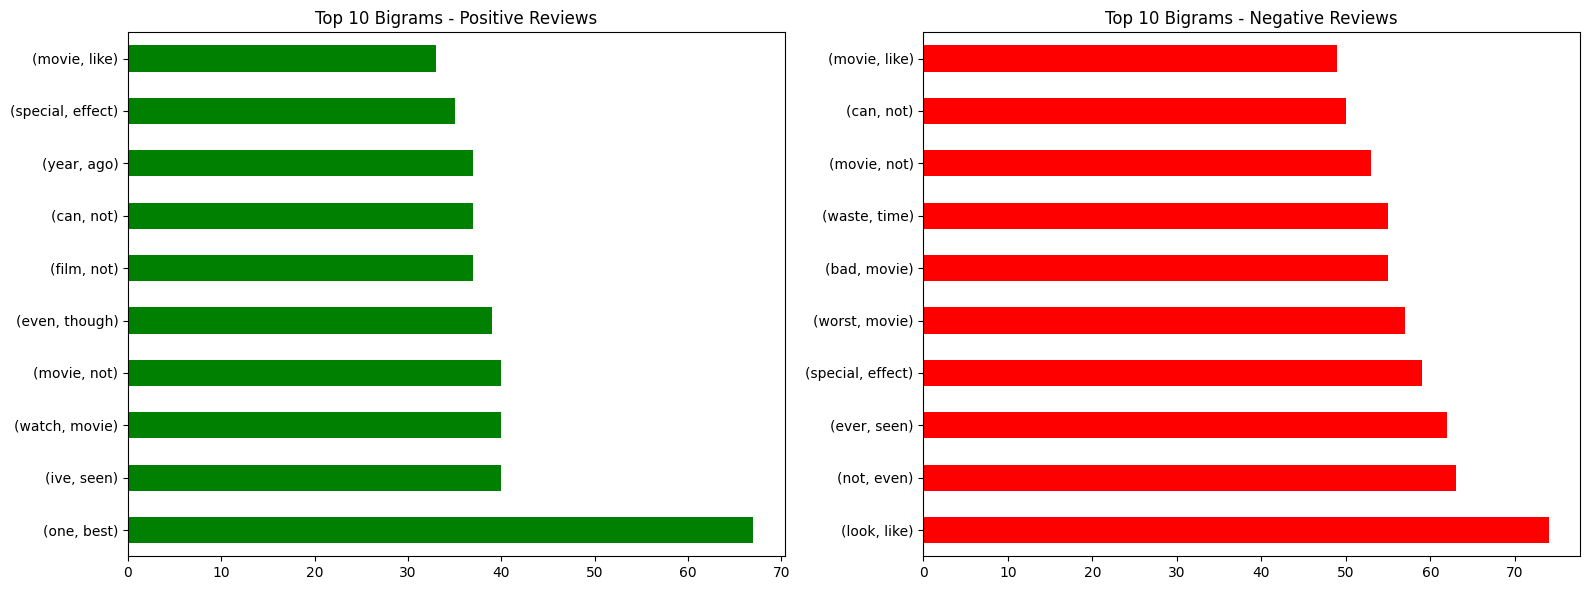

In [17]:
positive_reviews = data[data['sentiment'] == 'positive']['lemmatized']
negative_reviews = data[data['sentiment'] == 'negative']['lemmatized']

positive_tokens = sum(positive_reviews.tolist(), [])
negative_tokens = sum(negative_reviews.tolist(), [])

positive_bigrams = pd.Series(nltk.ngrams(positive_tokens, 2)).value_counts()[:10]
negative_bigrams = pd.Series(nltk.ngrams(negative_tokens, 2)).value_counts()[:10]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

positive_bigrams.plot(kind='barh', ax=axes[0], color='green', title='Top 10 Bigrams - Positive Reviews')
negative_bigrams.plot(kind='barh', ax=axes[1], color='red', title='Top 10 Bigrams - Negative Reviews')

plt.tight_layout()
plt.show()

## Named Entity Recognition
Using spaCy to detect and extract person names mentioned across reviews. Only full names (two or more words) are kept to filter out noise and fictional single-name characters.

**Limitation:** spaCy's NER model is a general-purpose model not specifically trained on movie review data. As a result it cannot distinguish between real people (actors, directors) and fictional characters (James Bond, Miss Dunne). This is a known challenge when applying general NER models to domain-specific text.

In [18]:


nlp = spacy.load("en_core_web_sm")

all_persons = []

for review in data['review'][:500]:
    doc = nlp(review)
    for ent in doc.ents:
        if ent.label_ == "PERSON"and len(ent.text.split()) >= 2:
            all_persons.append(ent.text)


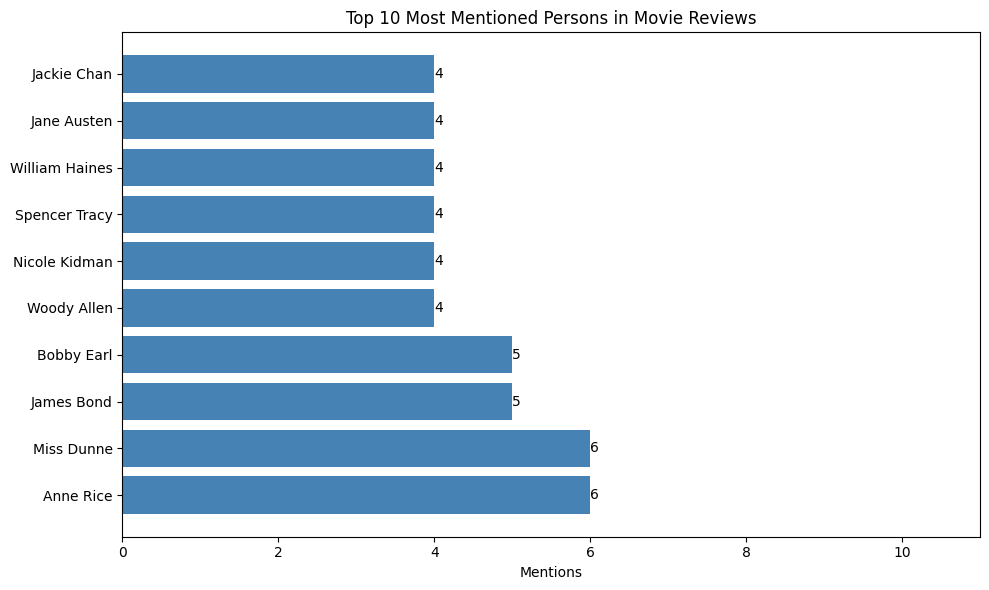

In [19]:
person_freq = Counter(all_persons).most_common(10)
labels = [item[0] for item in person_freq]
values = [item[1] for item in person_freq]
plt.figure(figsize=(10, 6))
bars = plt.barh(labels, values, color='steelblue')
plt.bar_label(bars)
plt.title('Top 10 Most Mentioned Persons in Movie Reviews')
plt.xlabel('Mentions')
plt.xlim(0, max(values) + 5)
plt.tight_layout()
plt.show()

## Sentiment Classification
Building and comparing three machine learning models to classify reviews as positive or negative using TF-IDF vectorization. The models compared are Logistic Regression, Naive Bayes, and Linear SVM.

In [20]:
tfidf = TfidfVectorizer(max_features=5000)
tf = tfidf.fit_transform(data["no_punct"])

In [21]:
x_train, x_test, y_train, y_test = train_test_split(tf, y, test_size=0.3, random_state = 7)

In [22]:
lr = LogisticRegression(random_state=1).fit(x_train, y_train)

In [23]:
y_pred_lr = lr.predict(x_test)

In [24]:
accuracy_score(y_pred_lr,y_test)

0.815

In [25]:
print(classification_report(y_test, y_pred_lr, zero_division=0))

              precision    recall  f1-score   support

    negative       0.86      0.76      0.81       305
    positive       0.78      0.87      0.82       295

    accuracy                           0.81       600
   macro avg       0.82      0.82      0.81       600
weighted avg       0.82      0.81      0.81       600



In [26]:
nb = MultinomialNB().fit(x_train, y_train)
y_pred_nb = nb.predict(x_test)
accuracy_score(y_pred_nb, y_test)

0.83

In [27]:
print(classification_report(y_test, y_pred_nb, zero_division=0))

              precision    recall  f1-score   support

    negative       0.83      0.84      0.83       305
    positive       0.83      0.82      0.83       295

    accuracy                           0.83       600
   macro avg       0.83      0.83      0.83       600
weighted avg       0.83      0.83      0.83       600



In [28]:
svm = SGDClassifier().fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)
accuracy_score(y_pred_svm, y_test)

0.8316666666666667

In [29]:
print(classification_report(y_test, y_pred_svm, zero_division=0))

              precision    recall  f1-score   support

    negative       0.84      0.83      0.83       305
    positive       0.83      0.83      0.83       295

    accuracy                           0.83       600
   macro avg       0.83      0.83      0.83       600
weighted avg       0.83      0.83      0.83       600



## Model Comparison
Visualizing the accuracy of all three models to identify the best performer.

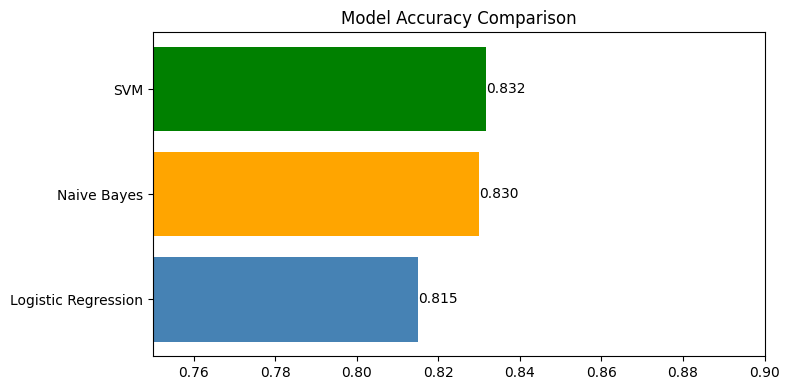

In [30]:
models = ['Logistic Regression', 'Naive Bayes', 'SVM']
scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_svm)
]

plt.figure(figsize=(8, 4))
bars = plt.barh(models, scores, color=['steelblue', 'orange', 'green'])
plt.bar_label(bars, fmt='%.3f')
plt.xlim(0.75, 0.90)
plt.title('Model Accuracy Comparison')
plt.tight_layout()
plt.show()